# Phase 2 - Exploratory Data Analysis

## 1.Load cleaned data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading cleaned data into the notebok
data = pd.read_csv("../data/processed/results_cleaned.csv")

# CSVs reload dates as string, so convert again
data['date'] = pd.to_datetime(data['date'])

data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24184 entries, 0 to 24183
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               24184 non-null  datetime64[ns]
 1   home_team          24184 non-null  object        
 2   away_team          24184 non-null  object        
 3   home_score         24184 non-null  int64         
 4   away_score         24184 non-null  int64         
 5   tournament         24184 non-null  object        
 6   city               24184 non-null  object        
 7   country            24184 non-null  object        
 8   neutral            24184 non-null  bool          
 9   home_ranking       24184 non-null  float64       
 10  country_abrv_x     24184 non-null  object        
 11  home_points        24184 non-null  float64       
 12  previous_points_x  24184 non-null  float64       
 13  rank_change_x      24184 non-null  float64       
 14  confed

## 2. Sanity checks

In [3]:
print("Shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

print("\nDtypes:")
print(data.dtypes)

print("\nSummary statistics:")
print(data.describe())

print("\nMissing values:")
print(data.isna().sum())

print("\nDuplicate rows:", data.duplicated().sum())

print("\nDate range:")
print(data["date"].min(), "to", data["date"].max())

Shape: (24184, 21)

Columns:
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'home_ranking', 'country_abrv_x', 'home_points', 'previous_points_x', 'rank_change_x', 'confederation_x', 'away_ranking', 'country_abrv_y', 'away_points', 'previous_points_y', 'rank_change_y', 'confederation_y']

Dtypes:
date                 datetime64[ns]
home_team                    object
away_team                    object
home_score                    int64
away_score                    int64
tournament                   object
city                         object
country                      object
neutral                        bool
home_ranking                float64
country_abrv_x               object
home_points                 float64
previous_points_x           float64
rank_change_x               float64
confederation_x              object
away_ranking                float64
country_abrv_y               object
away_points                 flo

## 3. Create analysis columns

In [4]:
# Creating goal_diff, result, rank_diff and points_diff columns

# Goal difference from the home team perspective
data['goal_diff'] = data['home_score'] - data['away_score']

# Result from the home team perspective --> usinng np.select to assign values based on conditions
data['result'] = np.select(
    [
        data["home_score"] > data["away_score"], # home win
        data["home_score"] < data["away_score"], # away win
        data["home_score"] == data["away_score"] # draw
    ],
    [
        'home_win',
        'away_win',
        'draw',
    ],
    default='unknown'
)

# Positive value means home team is stronger
# FIFA ranking works like this 1=strongest, so we need to reverse the order for the difference
data['rank_diff'] = data['away_ranking'] - data['home_ranking']

# Points difference from the home team perspective
data['points_diff'] = data['home_points'] - data['away_points']

# Displaying the data
display (data[[
    "home_team", "away_team",
    "home_score", "away_score",
    "home_ranking", "away_ranking",
    "goal_diff", "result", "rank_diff", "points_diff"
]].head())

,home_team,away_team,home_score,away_score,home_ranking,away_ranking,goal_diff,result,rank_diff,points_diff
0,Ghana,Mali,1,1,39.0,69.0,0,draw,30.0,12.0
1,Gabon,Burkina Faso,1,1,55.0,97.0,0,draw,42.0,16.0
2,Kuwait,Lebanon,2,0,71.0,161.0,2,home_win,90.0,21.0
3,Burkina Faso,Mali,1,0,97.0,69.0,1,home_win,-28.0,-11.0
4,Gabon,Ghana,2,3,55.0,39.0,-1,away_win,-16.0,-7.0


## 4. Q1: Do higher-ranked teams win more?

In [5]:
# Goal: To compare match outcomes when: home is much stronger, homes is slightly stronger
# teams are about even, and away is stronger. 

# How to do it: Putting rank_diff into categories
bins = [-np.inf, -30, -10, -1, 1, 10, 30, np.inf] # what this do is to create bins for the rank_diff values. The bins are defined by the edges specified in the list.
labels = [
    "away much stronger",
    "away stronger", 
    "away slightly stronger",
    "about even",
    "home slightly stronger", 
    "home stronger",
    "home much stronger",
]

data['rank_diff_bin'] = pd.cut(
    data['rank_diff'], 
    bins=bins, 
    labels=labels,
    include_lowest=True
)

# Now we can look at the distribution of results within each rank_diff_bin category. 
# This will help us understand how the strength difference between teams 
# (as measured by their FIFA rankings) affects match outcomes.
q1_long = (
    data.groupby("rank_diff_bin", observed=False)["result"]
    .value_counts(normalize=True)
    .rename("pct(%)") # Percentage of each result within each rank_diff_bin
    .mul(100)
    .reset_index()
)

display(q1_long.head(25))

,rank_diff_bin,result,pct(%)
0,away much stronger,away_win,54.365541
1,away much stronger,draw,25.245302
2,away much stronger,home_win,20.389157
3,away stronger,away_win,36.536215
4,away stronger,home_win,35.543224
5,away stronger,draw,27.920561
6,away slightly stronger,home_win,43.085106
7,away slightly stronger,draw,29.202128
8,away slightly stronger,away_win,27.712766
9,about even,home_win,47.902098


In [6]:
# Checking the distribution of matches across the rank_diff_bin categories 
# to ensure we have enough data in each bin for meaningful analysis.
bin_counts = data["rank_diff_bin"].value_counts().sort_index()
print(bin_counts)

rank_diff_bin
away much stronger        6013
away stronger             3424
away slightly stronger    1880
about even                 286
home slightly stronger    1946
home stronger             3723
home much stronger        6912
Name: count, dtype: int64


In [7]:
# Cleaner tabler for the report
q1_table = (
    q1_long
    .pivot(index="rank_diff_bin", columns="result", values="pct(%)")
    .fillna(0) # Fill NaN values with 0
)
display(q1_table.round(2))

result,away_win,draw,home_win
rank_diff_bin,,,
away much stronger,54.37,25.25,20.39
away stronger,36.54,27.92,35.54
away slightly stronger,27.71,29.20,43.09
about even,23.43,28.67,47.90
home slightly stronger,22.30,28.21,49.49
home stronger,17.65,25.44,56.92
home much stronger,8.15,17.00,74.86


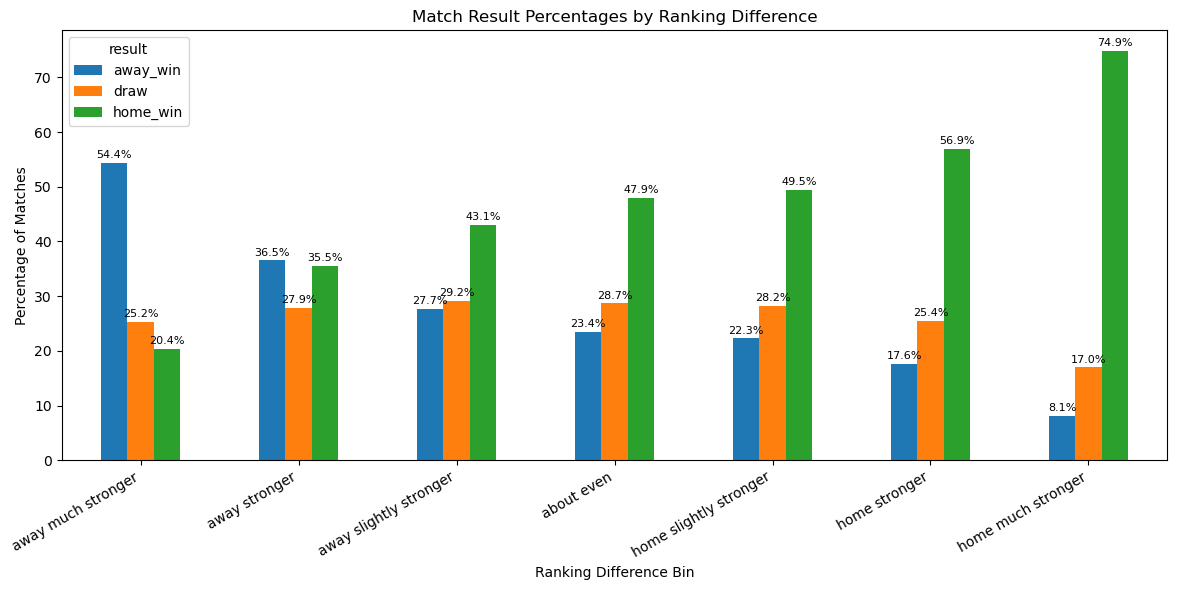

In [8]:
# Visualizations
ax = q1_table.plot(kind="bar", figsize=(12, 6))

plt.title("Match Result Percentages by Ranking Difference")
plt.xlabel("Ranking Difference Bin")
plt.ylabel("Percentage of Matches")
plt.xticks(rotation=30, ha="right")

# Add percentage labels to each bar
for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%" if bar.get_height() > 0 else ""
        for bar in container
    ]
    ax.bar_label(container, labels=labels, padding=2, fontsize=8)

plt.tight_layout()
plt.show()



### Interpretation: 
As we can see in the graph, as the stronger team’s advantage increases, the percentage for the stronger team to win also increases. Even more interestingly, when the teams are about even in terms of strength, the home team tends to win about twice as often as the away team. I think this graph strongly aligns with my original thought that the home team has an advantage regardless of whether it is stronger or not. This can also be seen when the away team is “stronger,” since the chances of winning in this data are still fairly close. Even more noticeably, when the away team is only “slightly stronger,” the graph shows that the home team still tends to win more often than the away team. Overall, this is strong evidence that home teams have a real advantage in this dataset. However, the “about even” category has fewer matches than the other bins, so that specific comparison should be interpreted a little more carefully.

In [9]:
# Checking the neutral matches only since home advantage can distort the results
# This matters to the project since the world cup is normally played in neutral sites only

neutral_only = data[data["neutral"] == True].copy()

print("Number of neutral matches:", len(neutral_only))


Number of neutral matches: 6238


In [10]:
# Repeating same logic as above for the neutral matches only
neutral_only['rank_diff_bin'] = pd.cut(
    neutral_only['rank_diff'], 
    bins=bins, 
    labels=labels,
    include_lowest=True
)

neutral_q1_long = (
    neutral_only.groupby("rank_diff_bin", observed=False)["result"]
    .value_counts(normalize=True)
    .rename("pct(%)") # Percentage of each result within each rank_diff_bin
    .mul(100)
    .reset_index()
)

neutral_q1_table = (
    neutral_q1_long
    .pivot(index="rank_diff_bin", columns="result", values="pct(%)")
    .fillna(0) # Fill NaN values with 0
)

display(neutral_q1_table.round(2))

result,away_win,draw,home_win
rank_diff_bin,,,
20.4%,62.73,21.46,15.81
35.5%,45.63,25.78,28.59
43.1%,36.82,27.80,35.38
47.9%,32.05,24.36,43.59
49.5%,29.14,28.64,42.22
56.9%,22.52,27.84,49.64
74.9%,11.79,21.69,66.52


In [11]:
# Checkiing how many matches fall in each category
neutral_bin_counts = neutral_only["rank_diff_bin"].value_counts().sort_index()
print(neutral_bin_counts)

rank_diff_bin
20.4%    1328
35.5%     927
43.1%     554
47.9%      78
49.5%     604
56.9%    1110
74.9%    1637
Name: count, dtype: int64


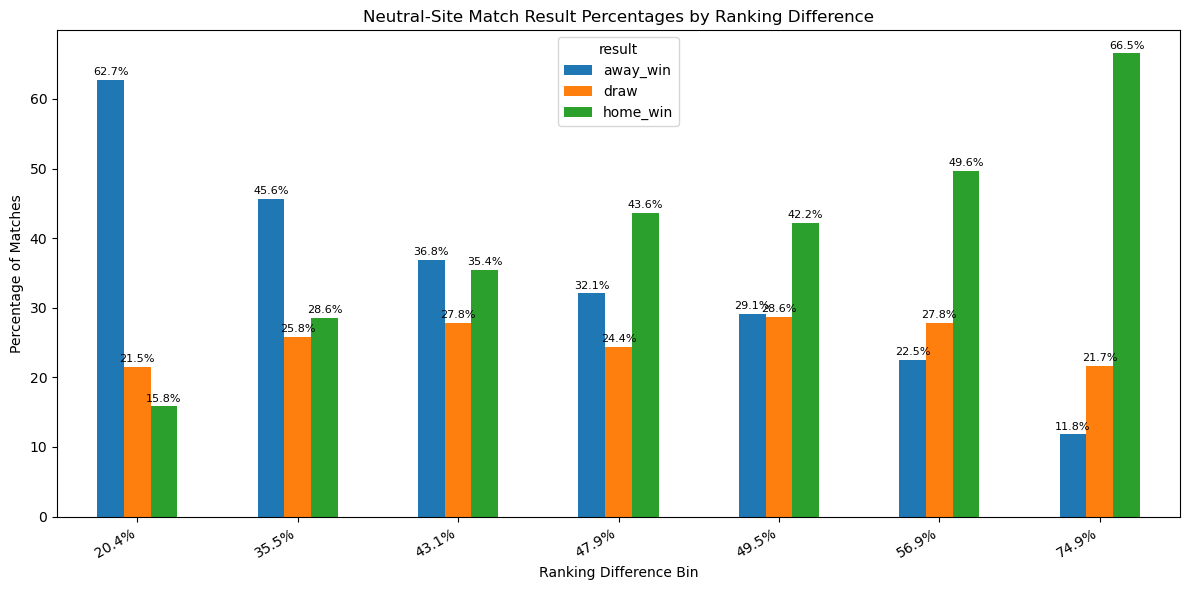

In [12]:
# plotting the neutral matches only
ax = neutral_q1_table.plot(kind="bar", figsize=(12, 6))

plt.title("Neutral-Site Match Result Percentages by Ranking Difference")
plt.xlabel("Ranking Difference Bin")
plt.ylabel("Percentage of Matches")
plt.xticks(rotation=30, ha="right")

for container in ax.containers:
    labels_for_bars = [
        f"{bar.get_height():.1f}%" if bar.get_height() > 0 else ""
        for bar in container
    ]
    ax.bar_label(container, labels=labels_for_bars, padding=2, fontsize=8)

plt.tight_layout()
plt.show()

### Interpretation
When looking at the match results in the same way but using neutral-site matches only (where the game is not played in either team’s country), we can see how the numbers when the rankings are about even are closer to each other. This could imply a more even game, which fits the World Cup well since those matches are usually played at neutral sites. The greatest change was in the percentage of wins when the away team was much stronger. With site bias included, it was about 54%, but here it rises to about 62%, which suggests that removing home-site bias makes the ranking advantage show up more clearly. Even so, it is still visible that the home side tends to perform better in several categories. Overall, this suggests that neutral sites reduce some of the home-advantage effect, but stronger teams still tend to win more often.

## 5. Q2: How often do underdogs wins?

In [15]:
# Underdog: the team with the worse FIFA ranking by at least 10 ranking places
# Because if one team is 1 spot worse, calling it an "underdog" is not very meaningful

# underdog = team with larger ranking number
thershold = 10
q2_data = data[data["rank_diff"].abs() >= thershold].copy()

# Abolute size of the ranking gap
q2_data["rank_gap"] = q2_data["rank_diff"].abs()

# whihc side is the underdog? 
q2_data["underdog_side"] = np.select(
    [
        q2_data["home_ranking"] > q2_data["away_ranking"], # away is underdog
        q2_data["away_ranking"] > q2_data["home_ranking"], # home is underdog
    ],
    [
        "home",
        "away"
    ],
    default="none"
)

# Result from the underdog perspective
q2_data["underdog_result"] = np.select(
    [
        (q2_data["home_ranking"] > q2_data["away_ranking"]) & (q2_data["home_score"] > q2_data["away_score"]), # away underdog win
        (q2_data["away_ranking"] > q2_data["home_ranking"]) & (q2_data["away_score"] > q2_data["home_score"]), # home underdog win
        q2_data["home_score"] == q2_data["away_score"],
    ],
    [
        "win",
        "win",
        "draw"
    ],
    default="loss"
)

print("Matches with a meaningful underdog:", len(q2_data))

display(q2_data[[
    "home_team", "away_team",
    "home_ranking", "away_ranking",
    "home_score", "away_score",
    "rank_gap", "underdog_side", "underdog_result"
]].head(10))


Matches with a meaningful underdog: 20306


,home_team,away_team,home_ranking,away_ranking,home_score,away_score,rank_gap,underdog_side,underdog_result
0,Ghana,Mali,39.0,69.0,1,1,30.0,away,draw
1,Gabon,Burkina Faso,55.0,97.0,1,1,42.0,away,draw
2,Kuwait,Lebanon,71.0,161.0,2,0,90.0,away,loss
3,Burkina Faso,Mali,97.0,69.0,1,0,28.0,home,win
4,Gabon,Ghana,55.0,39.0,2,3,16.0,home,loss
5,Uganda,Tanzania,92.0,80.0,3,1,12.0,home,win
6,Angola,Zimbabwe,102.0,54.0,1,1,48.0,home,draw
7,Botswana,South Africa,139.0,124.0,0,2,15.0,home,loss
8,Senegal,Algeria,51.0,30.0,1,2,21.0,home,loss
9,Tunisia,Bulgaria,38.0,26.0,3,0,12.0,home,win


## Sanity-check of the logic ##

In [16]:
print(q2_data["underdog_side"].value_counts())
print()
print(q2_data["underdog_result"].value_counts())
print()

display(q2_data.sample(10, random_state=42)[[
    "home_team", "away_team",
    "home_ranking", "away_ranking",
    "home_score", "away_score",
    "rank_gap", "underdog_side", "underdog_result"
]]
)

underdog_side
away    10869
home     9437
Name: count, dtype: int64

underdog_result
loss    11933
draw     4670
win      3703
Name: count, dtype: int64



,home_team,away_team,home_ranking,away_ranking,home_score,away_score,rank_gap,underdog_side,underdog_result
6625,Northern Ireland,Greece,107.0,48.0,0,2,59.0,home,loss
8135,Hong Kong,Brazil,134.0,1.0,1,7,133.0,home,loss
21632,Nigeria,Guinea-Bissau,35.0,118.0,0,1,83.0,away,win
7077,Rwanda,Zimbabwe,104.0,48.0,2,2,56.0,home,draw
8940,Turkey,North Macedonia,14.0,91.0,0,1,77.0,away,win
17257,Republic of Ireland,Wales,24.0,12.0,0,0,12.0,home,draw
2407,Croatia,Slovenia,25.0,89.0,3,3,64.0,away,draw
12035,Estonia,Latvia,99.0,46.0,0,0,53.0,home,draw
236,Kuwait,Malaysia,71.0,91.0,2,0,20.0,away,loss
8388,Australia,Argentina,57.0,3.0,2,4,54.0,home,loss


In [19]:
# Table: how often does the underdog win, lose or draw?
# overall underdog win rate
q2_overall = (
    q2_data["underdog_result"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(["win", "draw", "loss"]) # to ensure the order of the results is consistent
    .fillna(0) # Fill NaN values with 0, in case there are no matches in a category
    .rename("pct(%)")
)

display(q2_overall.round(2))
print(f"Overall underdog win rate: {q2_overall['win']:.2f}%")

underdog_result
win     18.24
draw    23.00
loss    58.77
Name: pct(%), dtype: float64

Overall underdog win rate: 18.24%


## Important ## 
As we can see, overall, the winning rate for the underdog team fro our data is about 18.24%. Which, I think it is a lot bigger than I thought. I should dig deeper to see how much of ran difference was in between these underdog. 

## Breaking down the data by raking-gap sizes ##

In [20]:
# Why: because an underdo that is only 10 spots worse is diff
# from one that 50+ spots worse

gap_bins = [10, 20, 30, 40, 50, np.inf]
gap_labels = [
    "10-19",
    "20-29",
    "30-39",
    "40-49",
    "50+"
]

# Creating rank_gap_bin column to categorize the underdog matches based on the size of the ranking gap
q2_data["rank_gap_bin"] = pd.cut(
    q2_data["rank_gap"],
    bins=gap_bins,
    labels=gap_labels,
    right=False,
    include_lowest=True
)

# Grouping by rank_gap_bin and underdog_result to calculate the percentage of each result within each gap bin
q2_long = (
    q2_data.groupby('rank_gap_bin', observed=False)["underdog_result"]
    .value_counts(normalize=True)
    .rename("pct(%)")
    .mul(100)
    .reset_index()
)

q2_table = (
    q2_long
    .pivot(index="rank_gap_bin", columns="underdog_result", values="pct(%)")
    .reindex(columns=["win", "draw", "loss"]) # to ensure the order of the results is consistent
    .fillna(0) # Fill NaN values with 0, in case there are no matches in a category
)

display(q2_table.round(2))

gap_counts = q2_data["rank_gap_bin"].value_counts().sort_index()
print(gap_counts)



underdog_result,win,draw,loss
rank_gap_bin,,,
10-19,27.90,27.95,44.15
20-29,24.34,25.39,50.27
30-39,21.95,25.43,52.62
40-49,17.14,24.77,58.09
50+,10.05,18.26,71.68


rank_gap_bin
10-19    3857
20-29    3356
30-39    2784
40-49    2293
50+      8016
Name: count, dtype: int64


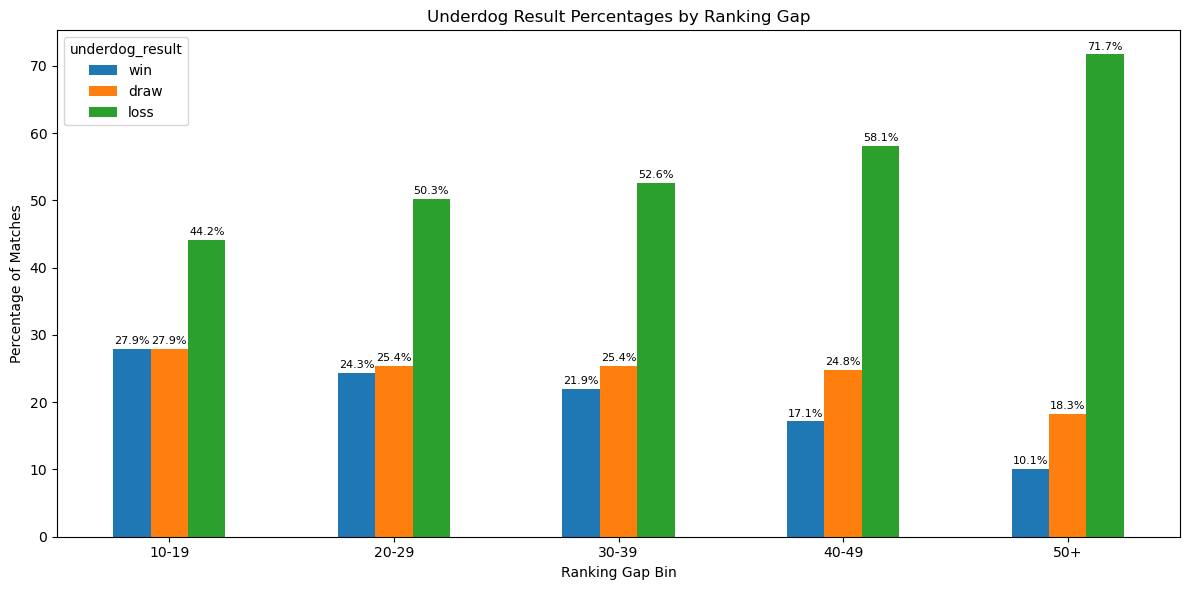

In [21]:
# Plotting the pivot like Q1
ax = q2_table.plot(kind='bar', figsize=(12, 6))

plt.title("Underdog Result Percentages by Ranking Gap")
plt.xlabel("Ranking Gap Bin")
plt.ylabel("Percentage of Matches")
plt.xticks(rotation=0)

for container in ax.containers:
    labels_for_bars = [
        f"{bar.get_height():.1f}%" if bar.get_height() > 0 else ""
        for bar in container
    ]
    ax.bar_label(container, labels=labels_for_bars, padding=2, fontsize=8)

plt.tight_layout()
plt.show()

## Interpretation ##
As we can see in the graph, when the ranking gap is smaller, the underdog has a better chance to win or draw. As the ranking gap gets larger, the underdog win percentage generally goes down and losses become more frequent. This means upsets are still possible, but they are less likely when the stronger team has a much bigger ranking advantage. Overall, this supports the idea that FIFA ranking difference is useful for prediction, while still showing that soccer remains uncertain and underdogs can still win.

## 6. Q3: Are recent goals predictive?

## 7. Key findings and takeaways